# Modelo Red Neuronal con datos de viajes por minuto entre estaciones

Manteniendo el problema de clasificación se intenta minimizar la influencia de la clase dominante 1

In [1]:
version = "7_4"

In [2]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [3]:
with open("../../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [4]:
df_model = df_data.drop(columns=[
    "ride_id",
    "ended_at",
    "time_hms_ms",
    "member_casual",
    "start_station_id",
    "end_station_id",
    "month",
    "day",
    "temperature",
    "wind_speed",
    "precipitation",
    "relative_humidity",
    "snow_depth",
    "hour_float"
])

In [5]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [6]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [7]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos
count,9.073410e+06,9.073410e+06,9073410,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06
mean,1.451035e+03,1.451958e+03,2023-03-15 06:23:51.479779072,1.048204e+00,2.022696e+03,-1.495024e-02,-1.812192e-03,8.774936e-03,4.883809e-05,1.967412e-03,-3.315338e-01,-2.758742e-01,-9.310089e-02,-2.660463e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.519273e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,1.358000e+03,1.358000e+03,2022-08-06 17:06:00,1.000000e+00,2.022000e+03,-7.493464e-01,-6.917960e-01,-7.628922e-01,-9.970427e-02,-5.614845e-02,-9.362641e-01,-8.029042e-01,-8.660254e-01,-8.660254e-01
50%,1.447000e+03,1.448000e+03,2023-04-13 19:23:00,1.000000e+00,2.023000e+03,1.895027e-01,-8.000990e-02,1.485145e-02,-9.970427e-02,-5.614845e-02,-6.025698e-01,-3.916012e-01,-2.449294e-16,-5.000000e-01
75%,1.565000e+03,1.565000e+03,2023-09-10 20:57:00,1.000000e+00,2.023000e+03,7.707278e-01,6.198615e-01,7.945084e-01,-9.970427e-02,-5.614845e-02,2.005080e-01,1.192704e-01,5.000000e-01,5.000000e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,9.000000e+00,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,2.191965e+02,2.176947e+02,NaN,2.348621e-01,6.859159e-01,1.003718e+00,1.000607e+00,9.993908e-01,9.976954e-01,1.017557e+00,6.781692e-01,5.950339e-01,7.072976e-01,6.482914e-01


In [8]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
10000,5,1362,2022-06-21 00:57:00,1,2022,1.595537,0.115036,-1.872588,-0.099704,-0.056148,0.246788,0.969070,1.224647e-16,-1.000000e+00,False,True,False,False
10001,5,1362,2022-06-30 23:12:00,1,2022,1.607251,1.549199,-1.694654,-0.099704,-0.056148,-0.208836,0.977951,1.224647e-16,-1.000000e+00,False,True,False,False
10002,5,1362,2022-07-06 21:22:00,1,2022,0.976758,0.449277,0.293232,-0.099704,-0.056148,-0.636639,0.771162,-5.000000e-01,-8.660254e-01,False,True,False,False
10003,5,1362,2022-07-10 10:15:00,1,2022,0.056858,-1.307653,1.096805,-0.099704,-0.056148,0.442419,-0.896808,-5.000000e-01,-8.660254e-01,True,False,True,False
10004,5,1362,2022-07-14 18:18:00,1,2022,1.028438,-0.764584,-0.615571,-0.099704,-0.056148,-0.996974,0.077734,-5.000000e-01,-8.660254e-01,False,True,False,False
10005,5,1362,2022-08-13 14:58:00,1,2022,0.801047,0.344502,-0.797331,-0.099704,-0.056148,-0.700857,-0.713301,-8.660254e-01,-5.000000e-01,False,False,True,False
10006,5,1362,2022-08-22 11:15:00,1,2022,0.212242,-0.741637,1.378055,-0.099704,-0.056148,0.196731,-0.980458,-8.660254e-01,-5.000000e-01,False,True,False,False
10007,5,1362,2022-09-03 13:02:00,1,2022,0.660994,-0.630728,0.861473,-0.099704,-0.056148,-0.266257,-0.963902,-1.000000e+00,-1.836970e-16,True,False,True,False
10008,5,1362,2022-09-20 17:01:00,1,2022,1.279257,0.561730,-0.131514,-0.099704,-0.056148,-0.966768,-0.255657,-1.000000e+00,-1.836970e-16,False,True,False,False
10009,5,1362,2022-10-04 08:27:00,1,2022,-0.664936,-1.996051,0.989662,-0.099704,-0.056148,0.800339,-0.599548,-8.660254e-01,5.000000e-01,False,True,False,False


In [9]:
df_agg['n_viajes'].value_counts(normalize=False)

n_viajes
1    8671457
2     372173
3      24990
4       4098
5        565
6        103
7         19
8          4
9          1
Name: count, dtype: int64

Claramente hay un desajuste de datos

## Se divide la cantidad de viajes 1 en varias subclases

In [10]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1]

In [11]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
num_stations = len(le_station.classes_)

In [12]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1].copy()

def assign_subclass(row):
    if row['start_station_idx'] < (num_stations / 2):
        return 1  # Estaciones "bajas"
    else:
        # Estaciones "altas", subdividir por hora
        h = row['started_minute'].hour
        if h <= 10:
            return 2
        elif h <= 17:
            return 3
        else:
            return 4

df_agg.loc[df_class_1.index, 'subclass'] = df_class_1.apply(assign_subclass, axis=1)

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())


subclass
3.0    4163596
4.0    2190680
2.0    2172307
1.0     144874
Name: count, dtype: int64


### Se añaden el resto de clases (viajes) que faltan

Se mueve el resto de clases

In [13]:
mask = df_agg['n_viajes'] > 1
df_agg.loc[mask, 'subclass'] = df_agg.loc[mask, 'n_viajes'] + 3

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())


subclass
3.0     4163596
4.0     2190680
2.0     2172307
5.0      372173
1.0      144874
6.0       24990
7.0        4098
8.0         565
9.0         103
10.0         19
11.0          4
12.0          1
Name: count, dtype: int64


Se agrupan los viajes 8, 9 y 7 en una sola clase

In [14]:
mask = df_agg['subclass'] >= 8
df_agg.loc[mask, 'subclass'] = 8

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
3.0    4163596
4.0    2190680
2.0    2172307
5.0     372173
1.0     144874
6.0      24990
7.0       4098
8.0        692
Name: count, dtype: int64


In [15]:
# convertir a entero
df_agg['subclass'] = df_agg['subclass'].astype(int)

## Obtención de datos

In [16]:
x_context = df_agg.drop(columns=[
    "n_viajes",
    "started_minute",
    "start_station_idx",
    "end_station_idx",
    "subclass",
])

x_start = df_agg[[
    "start_station_idx",
]]

x_end = df_agg[[
    "end_station_idx",
]]

y = df_agg["subclass"]

In [17]:
x_context.head()

,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
0,2022,-1.379839,1.021427,1.326397,-0.099704,-0.056148,-0.416215,-0.909266,0.866025,5.000000e-01,False,False,False,True
1,2022,-0.612834,-0.276355,-0.807078,-0.099704,-0.056148,-0.717569,-0.696487,1.000000,6.123234e-17,False,False,True,False
2,2022,-1.156238,4.113864,0.687365,-0.099704,-0.056148,0.281155,-0.959662,1.000000,6.123234e-17,False,False,True,False
3,2022,-0.424108,-0.883141,-1.019270,-0.099704,-0.056148,-0.972183,-0.234223,1.000000,6.123234e-17,False,False,True,False
4,2022,-0.410327,-0.825775,-1.038403,-0.099704,-0.056148,-0.976781,-0.214238,1.000000,6.123234e-17,False,False,True,False


In [18]:
x_start.head()

,start_station_idx
0,0
1,0
2,0
3,0
4,0


In [19]:
x_end.head()

,end_station_idx
0,0
1,0
2,0
3,0
4,0


In [20]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: subclass, dtype: int64

## Compruebo que de verdad hay viajes de ida y vuelta con el mismo id

In [21]:
df_check = df_data["start_station_idx"] == df_data["end_station_idx"]

In [22]:
# Contar numero de True
n_same_station = df_check.sum()
print(f"Número de viajes de ida y vuelta con la misma estación de inicio y fin: {n_same_station}")

Número de viajes de ida y vuelta con la misma estación de inicio y fin: 615646


## Se continua diviendo los datos

In [23]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

In [24]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: subclass, dtype: int64

In [25]:
# El target empieza en 1 → lo pasamos a 0
y_cls = y - 1

num_classes = y_cls.max() + 1
print("Clases totales:", num_classes)

Clases totales: 8


In [26]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_train, x_end_test, y_train, y_test = \
    train_test_split(x_context, x_start, x_end, y_cls, test_size=0.2, random_state=42)

x_ctx_train, x_ctx_val, x_start_train, x_start_val, x_end_train, x_end_val, y_train, y_val = \
    train_test_split(x_ctx_train, x_start_train, x_end_train, y_train, test_size=0.2, random_state=42)


## Se calcula class_weight para evitar colpaso por dominación de la clase 1

In [27]:
y_train.head()

5821951    3
3590136    2
856459     3
8773699    2
2192692    1
Name: subclass, dtype: int64

In [28]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes_present = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weights = {i: w for i, w in zip(classes_present, class_weights)}
print(class_weights)


{np.int64(0): np.float64(7.8100380886799154), np.int64(1): np.float64(0.5216949217104818), np.int64(2): np.float64(0.27246309654917167), np.int64(3): np.float64(0.5179403978707919), np.int64(4): np.float64(3.0497829904877145), np.int64(5): np.float64(45.29061895551257), np.int64(6): np.float64(278.21876197776925), np.int64(7): np.float64(1616.6430957683742)}


In [29]:
print("Clases en train:", np.unique(y_train))
print("Clases totales:", np.arange(num_classes))


Clases en train: [0 1 2 3 4 5 6 7]
Clases totales: [0 1 2 3 4 5 6 7]


## Se continua con la creación del modelo

In [30]:
# import tensorflow as tf
# from tensorflow.keras import layers, Model, Input
# from tensorflow.keras.optimizers import Adam

# num_stations = len(le_station.classes_)
# num_features = x_context.shape[1]

# # Inputs
# input_start = Input(shape=(1,), name='start_station')
# input_end = Input(shape=(1,), name='end_station')
# input_context = Input(shape=(num_features,), name='context')

# # Embeddings
# embed_dim = int(np.ceil(np.sqrt(num_stations)))
# embed_start = layers.Embedding(num_stations, embed_dim)(input_start)
# embed_end = layers.Embedding(num_stations, embed_dim)(input_end)

# # Flatten embeddings
# flat_start = layers.Flatten()(embed_start)
# flat_end = layers.Flatten()(embed_end)

# # Concatenate everything
# x = layers.Concatenate()([flat_start, flat_end, input_context])
# x = layers.Dense(128, activation='relu')(x)
# x = layers.Dense(64, activation='relu')(x)
# x = layers.Dense(32, activation='relu')(x)

# # Output Softmax
# output = layers.Dense(num_classes, activation='softmax')(x)

# model = Model(inputs=[input_start, input_end, input_context], outputs=output)

# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()


In [31]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

num_stations = len(le_station.classes_)
num_features = x_context.shape[1]
l2_reg = 1e-4
drop_rate = 0.3

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = int(np.ceil(np.sqrt(num_stations)))
embed_start = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_start)
embed_end = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_end)

# Flatten
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

# Concatenate
x = layers.Concatenate()([flat_start, flat_end, input_context])

# Dense Block 1
x = layers.Dense(128,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
#x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 2
x = layers.Dense(64,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(
#x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 3
x = layers.Dense(32,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
#x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Output
output = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = Model(inputs=[input_start, input_end, input_context], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 44)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 44)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     13,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        264 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 192,040 (750.16 KB)

 Trainable params: 192,040 (750.16 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Entrenamiento
history = model.fit(
    {'start_station': x_start_train, 'end_station': x_end_train, 'context': x_ctx_train},
    y_train,
    validation_data=(
        {'start_station': x_start_val, 'end_station': x_end_val, 'context': x_ctx_val},
        y_val
    ),    
    batch_size=256,
    epochs=50,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.1346 - loss: 96.1732 - val_accuracy: 0.2327 - val_loss: 2.0352
Epoch 2/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - accuracy: 0.2551 - loss: 2.0224 - val_accuracy: 0.5247 - val_loss: 1.5432
Epoch 3/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - accuracy: 0.3589 - loss: 1.7743 - val_accuracy: 0.5084 - val_loss: 1.5238
Epoch 4/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - accuracy: 0.4907 - loss: 1.6513 - val_accuracy: 0.7804 - val_loss: 1.2182
Epoch 5/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.6106 - loss: 1.5857 - val_accuracy: 0.6778 - val_loss: 1.3143
Epoch 6/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step - accuracy: 0.6502 - loss: 1.5577 - val_accuracy: 0.6235 - val_loss: 1.3822
Epoch 7/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.6716 - loss: 1.5410 - val_accuracy: 0.8007 - val_loss: 1.1967
Epoch 8/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - accuracy:

In [33]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

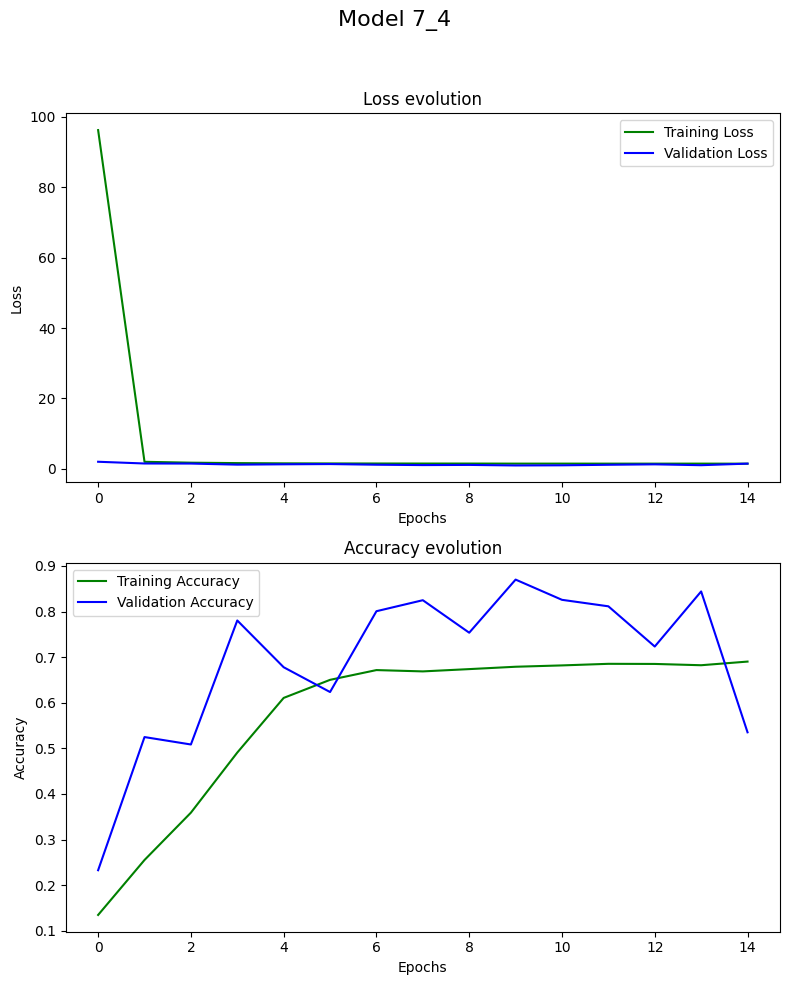

In [34]:
show_history(history, f"Model {version}")

In [35]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

## Evaluación del modelo

In [36]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'start_station': x_start_test, 'end_station': x_end_test, 'context': x_ctx_test},
    y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

56709/56709 - 48s - 847us/step - accuracy: 0.8703 - loss: 0.9876
Test metrics (loss, accuracy): [0.9876241683959961, 0.870261013507843]


# Prediccion del modelo

In [37]:
# Predicciones como probabilidades
y_pred_probs = model.predict({
    'start_station': x_start,
    'end_station': x_end,
    'context': x_context
}, batch_size=256)

print("Shape de predicciones:", y_pred_probs.shape)
# (num_ejemplos, num_classes)


35444/35444 ━━━━━━━━━━━━━━━━━━━━ 27s 748us/step
Shape de predicciones: (9073410, 8)


In [38]:
# Elegimos la clase con mayor probabilidad
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Clases predichas:", np.unique(y_pred_classes))


Clases predichas: [0 1 2 3 4 5 6 7]


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls, y_pred_classes)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls, y_pred_classes))

# Matriz de confusión
cm = confusion_matrix(y_cls, y_pred_classes)
print(cm)


Accuracy test: 0.8701618244959723
              precision    recall  f1-score   support

           0       0.86      1.00      0.92    144874
           1       0.98      0.86      0.92   2172307
           2       0.93      0.91      0.92   4163596
           3       0.85      0.95      0.90   2190680
           4       0.10      0.04      0.06    372173
           5       0.00      0.00      0.00     24990
           6       0.00      0.13      0.00      4098
           7       0.00      0.07      0.00       692

    accuracy                           0.87   9073410
   macro avg       0.46      0.50      0.47   9073410
weighted avg       0.88      0.87      0.87   9073410

[[ 144797      27      30      16       3       0       0       1]
 [   7412 1878525  111852   80892   21687       1   19423   52515]
 [   8660      10 3774656  138282  115050       0  126874      64]
 [   3732       0   18724 2080763    9567       0   50719   27175]
 [   4252   32512  159326  126253   16008      

## Se elimina la extensión de la categoría 1

In [42]:
y_cls.unique()

array([0, 4, 5, 6, 7, 2, 3, 1])

In [43]:
np.unique(y_pred_classes)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [44]:
conteo_clases = y_cls.value_counts()
print(conteo_clases)

subclass
2    4163596
3    2190680
1    2172307
4     372173
0     144874
5      24990
6       4098
7        692
Name: count, dtype: int64


In [45]:
mapping = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 2,
    5: 3,
    6: 4,
    7: 5
}

y_cls_real = y_cls.map(mapping)
y_pred_real = np.vectorize(lambda x: mapping.get(x, x))(y_pred_classes)

print(np.unique(y_pred_real))
print(y_cls_real.unique())


[1 2 3 4 5]
[1 2 3 4 5]


In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls_real, y_pred_real)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls_real, y_pred_real))

# Matriz de confusión
cm = confusion_matrix(y_cls_real, y_pred_real)
print(cm)

Accuracy test: 0.9109003120105892
              precision    recall  f1-score   support

           1       0.96      0.95      0.96   8671457
           2       0.10      0.04      0.06    372173
           3       0.00      0.00      0.00     24990
           4       0.00      0.13      0.00      4098
           5       0.00      0.07      0.00       692

    accuracy                           0.91   9073410
   macro avg       0.21      0.24      0.20   9073410
weighted avg       0.92      0.91      0.92   9073410

[[8248378  146307       1  197016   79755]
 [ 322343   16008       0   26312    7510]
 [  20073    1429       0    2616     872]
 [   3112     252       0     535     199]
 [    502      40       0      99      51]]
